2       2
                                 L       E  rs         rs
                               (----- - -------) (1 - ----)
                                    3         2       r[t]
               rs               r[t]    2 r[t]
m'[r[t]] (1 - ---- - r'[t]) == ---------------------------- + 
              r[t]                       m[r[t]]
 
                           2
                   rs r'[t]
>    m[r[t]] (------------------- + r''[t])
              2 r[t] (-rs + r[t])
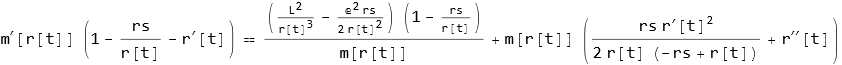

In [1]:
D[m[r[t]], r[t]] * (1 - rs/r[t] - r'[t]) == 
  m[r[t]] * (r''[t] + rs/(2*(r[t] - rs)*r[t]) * r'[t]^2) + 
  (1 - rs/r[t])/m[r[t]] * (L^2/r[t]^3 - rs*E^2/(2*r[t]^2))

In [11]:
(* your original pieces, as functions of r *)
P[r_] := 1 - rs/r - rdot[r]
A[r_] := rddot[r] + rs/(2*(r - rs)*r) * rdot[r]^2
B[r_] := (1 - rs/r) * (L^2/r^3 - rs*E^2/(2*r^2))


4                     5
{{u[r] -> Power[E, Inactive[Integrate][(2 rs K[1]  rddot[K[1]] - 2 K[1]  rddot[K[1]] - 
 
                    3           2       3
>            rs K[1]  rdot[K[1]] )/(K[1]  (-rs + K[1]) (rs - K[1] + K[1] rdot[K[1]])), 
 
>         {K[1], 1, r}]] C[1] + Power[E, 
 
                                       4                     5
>        Inactive[Integrate][(2 rs K[1]  rddot[K[1]] - 2 K[1]  rddot[K[1]] - 
 
                    3           2       3
>            rs K[1]  rdot[K[1]] )/(K[1]  (-rs + K[1]) (rs - K[1] + K[1] rdot[K[1]])), 
 
                                                  2   2      2            2   3
>         {K[1], 1, r}]] Inactive[Integrate][(-2 L  rs  + 4 L  rs K[2] + E  rs  K[2] - 
 
               2     2      2   2     2    2        3
>           2 L  K[2]  - 2 E  rs  K[2]  + E  rs K[2] ) / 
 
                                                  4                     5
>         (Power[E, Inactive[Integrate][(2 rs K[1]  rddot[K[1]] - 2 K[1]  rddot[K[1]] - 
 
                        3           2       3
>                rs K[1]  rdot[K[1]] )/(K[1]  (-rs + K[1]) (rs - K[1] + K[1] rdot[K[1]]))
 
                                       3
>              , {K[1], 1, K[2]}]] K[2]  (-rs + K[2]) (rs - K[2] + K[2] rdot[K[2]])), 
 
>        {K[2], 1, r}]}}
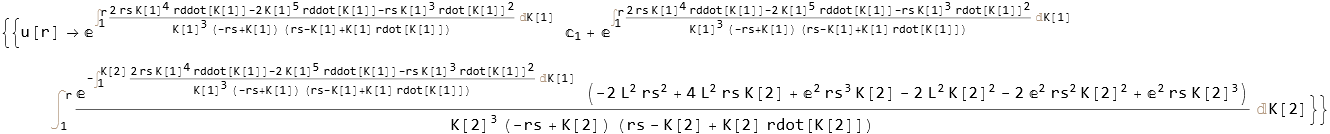

In [18]:

(* linearized ODE for u = m^2 *)
ode = u'[r] - (2*A[r]/P[r])*u[r] == 2*B[r]/P[r];
sol = DSolve[ode, u[r], r]


4                     5
{Sqrt[Power[E, Inactive[Integrate][(2 rs K[1]  rddot[K[1]] - 2 K[1]  rddot[K[1]] - 
 
                   3           2       3
>           rs K[1]  rdot[K[1]] )/(K[1]  (-rs + K[1]) (rs - K[1] + K[1] rdot[K[1]])), 
 
>        {K[1], 1, r}]] C[1] + Power[E, 
 
                                      4                     5
>       Inactive[Integrate][(2 rs K[1]  rddot[K[1]] - 2 K[1]  rddot[K[1]] - 
 
                   3           2       3
>           rs K[1]  rdot[K[1]] )/(K[1]  (-rs + K[1]) (rs - K[1] + K[1] rdot[K[1]])), 
 
                                                 2   2      2            2   3
>        {K[1], 1, r}]] Inactive[Integrate][(-2 L  rs  + 4 L  rs K[2] + E  rs  K[2] - 
 
              2     2      2   2     2    2        3
>          2 L  K[2]  - 2 E  rs  K[2]  + E  rs K[2] ) / 
 
                                                 4                     5
>        (Power[E, Inactive[Integrate][(2 rs K[1]  rddot[K[1]] - 2 K[1]  rddot[K[1]] - 
 
                       3           2       3
>               rs K[1]  rdot[K[1]] )/(K[1]  (-rs + K[1]) (rs - K[1] + K[1] rdot[K[1]]))\
 
                                      3
>             , {K[1], 1, K[2]}]] K[2]  (-rs + K[2]) (rs - K[2] + K[2] rdot[K[2]])), 
 
>       {K[2], 1, r}]]}
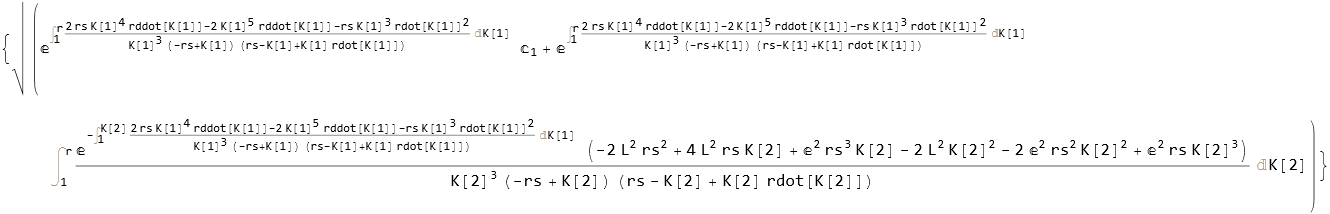

In [21]:

(* recover m *)
mSol = Sqrt[u[r]] /. sol